# Comparative Model Evaluation — Market Regime-Aware Stock Classification

Loads pre-trained baseline and tuned models directly — no retraining.

Covers:
- Stage 1 and Stage 2 full performance breakdown
- Per-class precision / recall / F1 analysis
- Statistical significance testing (McNemar's test)
- Regime-stratified Stage 2 performance
- Tuning analysis: why CV overestimated holdout
- Final model ranking and report-ready summary figure

In [1]:
import os, warnings, pickle
warnings.filterwarnings('ignore')
import logging
logging.getLogger('lightgbm').setLevel(logging.ERROR)
import xgboost as xgb
logging.getLogger('xgboost').setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2 as chi2_dist

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, precision_score, recall_score,
    cohen_kappa_score, matthews_corrcoef,
    roc_auc_score, brier_score_loss, log_loss, r2_score
)

SEED = 42
np.random.seed(SEED)

REGIME_NAMES = {0: 'Bullish', 1: 'Bearish', 2: 'High-Volatility'}
SIGNAL_NAMES = {0: 'Sell', 1: 'Hold', 2: 'Buy'}
MODEL_COLORS = {
    'Logistic Regression': '#3498db',
    'Random Forest': '#e67e22',
    'LightGBM': '#2ecc71'
}

os.makedirs('plots/evaluation', exist_ok=True)
os.makedirs('results', exist_ok=True)
print('Setup complete.')


Setup complete.


In [2]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

# ── Baseline models ──
baseline = {
    's1': {
        'Logistic Regression': load_pkl('models/trained/lr_s1.pkl'),
        'Random Forest':       load_pkl('models/trained/rf_s1.pkl'),
        'LightGBM':            load_pkl('models/trained/lgb_s1.pkl'),
        'XGBoost':             load_pkl('models/trained/xgb_s1.pkl'),
    },
    's2': {
        'Logistic Regression': load_pkl('models/trained/lr_s2.pkl'),
        'Random Forest':       load_pkl('models/trained/rf_s2.pkl'),
        'LightGBM':            load_pkl('models/trained/lgb_s2.pkl'),
        'XGBoost':             load_pkl('models/trained/xgb_s2.pkl'),
    }
}
scaler_s1 = load_pkl('models/trained/scaler_s1.pkl')
scaler_s2 = load_pkl('models/trained/scaler_s2.pkl')
print('Baseline models loaded.')

# ── Tuned models (if available) ──
TUNED_AVAILABLE = os.path.exists('models/tuned/lgb_s1.pkl')
if TUNED_AVAILABLE:
    tuned = {
        's1': {
            'Logistic Regression': load_pkl('models/tuned/lr_s1.pkl'),
            'Random Forest':       load_pkl('models/tuned/rf_s1.pkl'),
            'LightGBM':            load_pkl('models/tuned/lgb_s1.pkl'),
            'XGBoost':             load_pkl('models/tuned/xgb_s1.pkl'),
        },
        's2': {
            'Logistic Regression': load_pkl('models/tuned/lr_s2.pkl'),
            'Random Forest':       load_pkl('models/tuned/rf_s2.pkl'),
            'LightGBM':            load_pkl('models/tuned/lgb_s2.pkl'),
            'XGBoost':             load_pkl('models/tuned/xgb_s2.pkl'),
        }
    }
    scaler_s1_t = load_pkl('models/tuned/scaler_s1.pkl')
    scaler_s2_t = load_pkl('models/tuned/scaler_s2.pkl')
    print('Tuned models loaded.')
else:
    print('Tuned models not found — tuning comparison will use saved CSV results.')

Baseline models loaded.
Tuned models loaded.


In [3]:
# ── Stale PKL guard — runs immediately after model load ──────────────────────
# Scalers fitted on a DataFrame store feature_names_in_.
# If pkl files are from the old 16-feature run and the CSV is now 12-feature,
# scaler.transform() will KeyError mid-run. Catch it here with a clear message.

EXPECTED_S1 = 6    # 6 regime-discriminating features
EXPECTED_S2 = 13   # base(9) + interactions(4)

s1_n = getattr(scaler_s1, 'n_features_in_', None)
s2_n = getattr(scaler_s2, 'n_features_in_', None)

if s1_n != EXPECTED_S1 or s2_n != EXPECTED_S2:
    raise RuntimeError(
        f"Stale pkl files detected.\n"
        f"  scaler_s1 expects {s1_n} features, pipeline now uses {EXPECTED_S1} (S1).\n"
        f"  scaler_s2 expects {s2_n} features, pipeline now uses {EXPECTED_S2}.\n"
        f"Re-run ModelTraining.ipynb (all cells) to regenerate pkl files, then re-run this notebook."
    )

print(f"PKL version check passed: S1={s1_n} features, S2={s2_n} features.")


PKL version check passed: S1=6 features, S2=13 features.


---
## 2. Reconstruct Test Sets

In [4]:
df = pd.read_csv('data/features/sp500_panel_with_features.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

S1_FEATURES = [
    'Ret_Lag1', 'Ret_5d',
    'RSI',
    'ATR_Pct', 'Volatility_Ratio',
    'Return_Dispersion',
]  # 6 features

S2_FEATURES_BASE = [
    'Ret_Lag1', 'Ret_5d',
    'RSI',
    'ATR_Pct', 'Volatility_Ratio',
    'Price_vs_SMA50', 'Momentum_Deviation', 'BB_Pct',
    'Vol_Price_Trend',
]  # 9 features

INTERACTION_FEATURES = [
    'regime_pred', 'Dir_x_Ret5', 'Dir_x_RSI', 'Vol_x_ATR',
]
S2_FEATURES_REGIME = S2_FEATURES_BASE + INTERACTION_FEATURES  # 13 features

print(f'Loaded: {len(df):,} rows')
print(f'S1={len(S1_FEATURES)} features, S2={len(S2_FEATURES_REGIME)} features')


Loaded: 1,190,610 rows
S1=6 features, S2=13 features


In [5]:
# ── Stage 1 test set (regime labeling matches ModelTraining) ──────────────────
from scipy.stats import mode as scipy_mode

WINDOW = 20
market_daily = (
    df.groupby('Date')['Ret_Lag1'].mean()
    .reset_index().rename(columns={'Ret_Lag1': 'market_return'})
    .sort_values('Date')
)
market_daily['rolling_ret'] = market_daily['market_return'].rolling(WINDOW).mean()
market_daily['rolling_vol'] = market_daily['market_return'].rolling(WINDOW).std()
market_daily.dropna(inplace=True)

vol_hi = market_daily['rolling_vol'].quantile(0.80)
ret_hi = market_daily['rolling_ret'].quantile(0.65)
ret_lo = market_daily['rolling_ret'].quantile(0.35)

def assign_regime(row):
    if row['rolling_vol'] >= vol_hi: return 2
    elif row['rolling_ret'] >= ret_hi: return 0
    elif row['rolling_ret'] <= ret_lo: return 1
    else: return 0 if row['rolling_ret'] >= 0 else 1

market_daily['regime_raw'] = market_daily.apply(assign_regime, axis=1)

def rolling_mode(x):
    return int(scipy_mode(x, keepdims=True).mode[0])

market_daily['regime'] = (
    market_daily['regime_raw'].rolling(3, min_periods=1)
    .apply(rolling_mode, raw=True).astype(int)
)

stage1_df = (
    df.groupby('Date')[S1_FEATURES].mean().reset_index().sort_values('Date')
    .merge(market_daily[['Date', 'regime']], on='Date', how='inner')
    .dropna().reset_index(drop=True)
)

split_date_s1 = stage1_df['Date'].quantile(0.8)
test_s1  = stage1_df[stage1_df['Date'] > split_date_s1]
X_test_s1 = scaler_s1.transform(test_s1[S1_FEATURES].values)
y_test_s1 = test_s1['regime'].values
print(f'Stage 1 test: {len(y_test_s1)} dates | split at {split_date_s1.date()}')


Stage 1 test: 488 dates | split at 2024-01-02


In [6]:
# ── Stage 2 test set ──────────────────────────────────────────────────────────
def label_signal(series):
    low, high = series.quantile(0.15), series.quantile(0.85)
    if low == high:
        m = series.median()
        return pd.Series(np.where(series < m, 0, np.where(series > m, 2, 1)), index=series.index)
    return pd.cut(series, bins=[-np.inf, low, high, np.inf], labels=[0, 1, 2]).astype(int)

df['signal'] = df.groupby('Encoded_Ticker')['y_return_5d'].transform(label_signal).astype(int)

X_all_s1   = scaler_s1.transform(stage1_df[S1_FEATURES].values)
regime_map  = dict(zip(stage1_df['Date'], baseline['s1']['LightGBM'].predict(X_all_s1)))
df['regime_pred'] = df['Date'].map(regime_map).ffill().bfill().fillna(0).astype(int)
assert 'regime_pred' in df.columns

df['Regime_Direction'] = df['regime_pred'].map({0: 1, 1: -1, 2: 0}).astype(float)
df['Regime_VolFlag']   = (df['regime_pred'] == 2).astype(float)
df['Dir_x_Ret5']       = df['Regime_Direction'] * df['Ret_5d']
df['Dir_x_RSI']        = df['Regime_Direction'] * (df['RSI'] / 100.0)
df['Vol_x_ATR']        = df['Regime_VolFlag']   * df['ATR_Pct']

missing = [c for c in S2_FEATURES_REGIME if c not in df.columns]
assert not missing, f'Missing S2 columns: {missing}'

# Include regime_pred in test_s2 so regime-stratified analysis can use it
df_s2 = df[S2_FEATURES_REGIME + ['Date', 'signal']].dropna()
df_s2 = df_s2.sort_values('Date').reset_index(drop=True)

split_date_s2 = df_s2['Date'].quantile(0.8)
test_s2 = df_s2[df_s2['Date'] > split_date_s2].reset_index(drop=True)

X_test_s2 = scaler_s2.transform(test_s2[S2_FEATURES_REGIME].values)
y_test_s2  = test_s2['signal'].values
print(f'Stage 2 test: {len(y_test_s2):,} rows | split at {split_date_s2.date()}')
print(f'Signal dist: {dict(zip(*np.unique(y_test_s2, return_counts=True)))}')


Stage 2 test: 237,977 rows | split at 2024-01-17
Signal dist: {np.int64(0): np.int64(35927), np.int64(1): np.int64(166049), np.int64(2): np.int64(36001)}


In [7]:
preds_s1 = {name: m.predict(X_test_s1) for name, m in baseline['s1'].items()}
preds_s2 = {name: m.predict(X_test_s2) for name, m in baseline['s2'].items()}

if TUNED_AVAILABLE:
    X_test_s1_t = scaler_s1_t.transform(test_s1[S1_FEATURES].values)
    X_test_s2_t = scaler_s2_t.transform(test_s2[S2_FEATURES_REGIME].values)
    preds_s1_tuned = {name: m.predict(X_test_s1_t) for name, m in tuned['s1'].items()}
    preds_s2_tuned = {name: m.predict(X_test_s2_t) for name, m in tuned['s2'].items()}

print('Predictions ready.')
print('\nStage 1 Macro F1:')
for name, yp in preds_s1.items():
    print(f'  {name}: {f1_score(y_test_s1, yp, average="macro"):.4f}')
print('\nStage 2 Macro F1:')
for name, yp in preds_s2.items():
    print(f'  {name}: {f1_score(y_test_s2, yp, average="macro"):.4f}')

Predictions ready.

Stage 1 Macro F1:
  Logistic Regression: 0.6156
  Random Forest: 0.6499
  LightGBM: 0.6407
  XGBoost: 0.6464

Stage 2 Macro F1:
  Logistic Regression: 0.2902
  Random Forest: 0.2580
  LightGBM: 0.2739
  XGBoost: 0.2860


---
## 4. Stage 1 Evaluation

In [8]:
from sklearn.metrics import (
    balanced_accuracy_score, top_k_accuracy_score,
    average_precision_score
)
from scipy.stats import wilcoxon

def compute_metrics(y_true, y_pred, y_proba=None, n_classes=3):
    classes = list(range(n_classes))
    row = {
        'Accuracy':          accuracy_score(y_true, y_pred),
        'Balanced Acc':      balanced_accuracy_score(y_true, y_pred),
        'Macro F1':          f1_score(y_true, y_pred, average='macro'),
        'Weighted F1':       f1_score(y_true, y_pred, average='weighted'),
        'Macro Prec':        precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Macro Rec':         recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Kappa':             cohen_kappa_score(y_true, y_pred),
        'MCC':               matthews_corrcoef(y_true, y_pred),
        'R2 (ordinal)':      r2_score(y_true, y_pred),
    }
    if y_proba is not None:
        y_bin = label_binarize(y_true, classes=classes)
        row['ROC-AUC (OvR)'] = roc_auc_score(y_bin, y_proba, multi_class='ovr', average='macro')
        row['ROC-AUC (OvO)'] = roc_auc_score(y_bin, y_proba, multi_class='ovo', average='macro')
        row['Log Loss']       = log_loss(y_true, y_proba)
        row['Brier Score']    = float(np.mean([
            brier_score_loss(y_bin[:, c], y_proba[:, c]) for c in classes]))
        # Mean Average Precision (OvR)
        row['mAP (OvR)']     = average_precision_score(y_bin, y_proba, average='macro')
    return row

# ── Random + majority baselines ───────────────────────────────────────────────
rng            = np.random.default_rng(SEED)
rand_pred_s1   = rng.integers(0, 3, size=len(y_test_s1))
rand_proba_s1  = np.ones((len(y_test_s1), 3)) / 3.0
majority_s1    = np.full(len(y_test_s1), np.bincount(y_test_s1).argmax())

print(f'Random  Macro F1 (S1): {f1_score(y_test_s1, rand_pred_s1, average="macro"):.4f}')
print(f'Majority Macro F1 (S1): {f1_score(y_test_s1, majority_s1, average="macro"):.4f}')

# ── Stage 1 summary ──────────────────────────────────────────────────────────
s1_rows = []
for name, yp in preds_s1.items():
    yproba = baseline['s1'][name].predict_proba(X_test_s1)
    row = compute_metrics(y_test_s1, yp, yproba)
    row['Model'] = name; s1_rows.append(row)

s1_rows.append({**compute_metrics(y_test_s1, rand_pred_s1, rand_proba_s1),
                'Model': 'Random Baseline'})
s1_rows.append({**compute_metrics(y_test_s1, majority_s1),
                'Model': 'Majority Baseline'})

col_order = ['Model','Accuracy','Balanced Acc','Macro F1','Weighted F1',
             'Macro Prec','Macro Rec','Kappa','MCC','R2 (ordinal)',
             'ROC-AUC (OvR)','ROC-AUC (OvO)','Log Loss','Brier Score','mAP (OvR)']

s1_summary = pd.DataFrame(s1_rows).sort_values('Macro F1', ascending=False).reset_index(drop=True)
s1_summary = s1_summary[[c for c in col_order if c in s1_summary.columns]]
print('=== Stage 1 — All Metrics ===')
print(s1_summary.to_string(index=False))

per_class_s1 = []
for name, yp in preds_s1.items():
    rpt = classification_report(y_test_s1, yp, output_dict=True)
    for k, v in REGIME_NAMES.items():
        per_class_s1.append({'Model': name, 'Class': v,
                              'Precision': rpt[str(k)]['precision'],
                              'Recall':    rpt[str(k)]['recall'],
                              'F1':        rpt[str(k)]['f1-score'],
                              'Support':   int(rpt[str(k)]['support'])})
per_class_s1_df = pd.DataFrame(per_class_s1)


Random  Macro F1 (S1): 0.2707
Majority Macro F1 (S1): 0.2574
=== Stage 1 — All Metrics ===
              Model  Accuracy  Balanced Acc  Macro F1  Weighted F1  Macro Prec  Macro Rec     Kappa       MCC  R2 (ordinal)  ROC-AUC (OvR)  ROC-AUC (OvO)  Log Loss  Brier Score  mAP (OvR)
      Random Forest  0.711066      0.773830  0.649943     0.721204    0.615541   0.773830  0.477607  0.485701      0.003553       0.881015       0.881015  0.655875     0.129012   0.806604
            XGBoost  0.727459      0.751514  0.646359     0.711586    0.644395   0.751514  0.455791  0.470187      0.014812       0.858571       0.858571  0.733226     0.134946   0.801630
           LightGBM  0.709016      0.762779  0.640653     0.714245    0.610299   0.762779  0.462384  0.468695     -0.052743       0.882217       0.882217  0.643295     0.128507   0.828827
Logistic Regression  0.692623      0.741027  0.615559     0.709800    0.591926   0.741027  0.455750  0.467182     -0.131558       0.871700       0.871700  0.

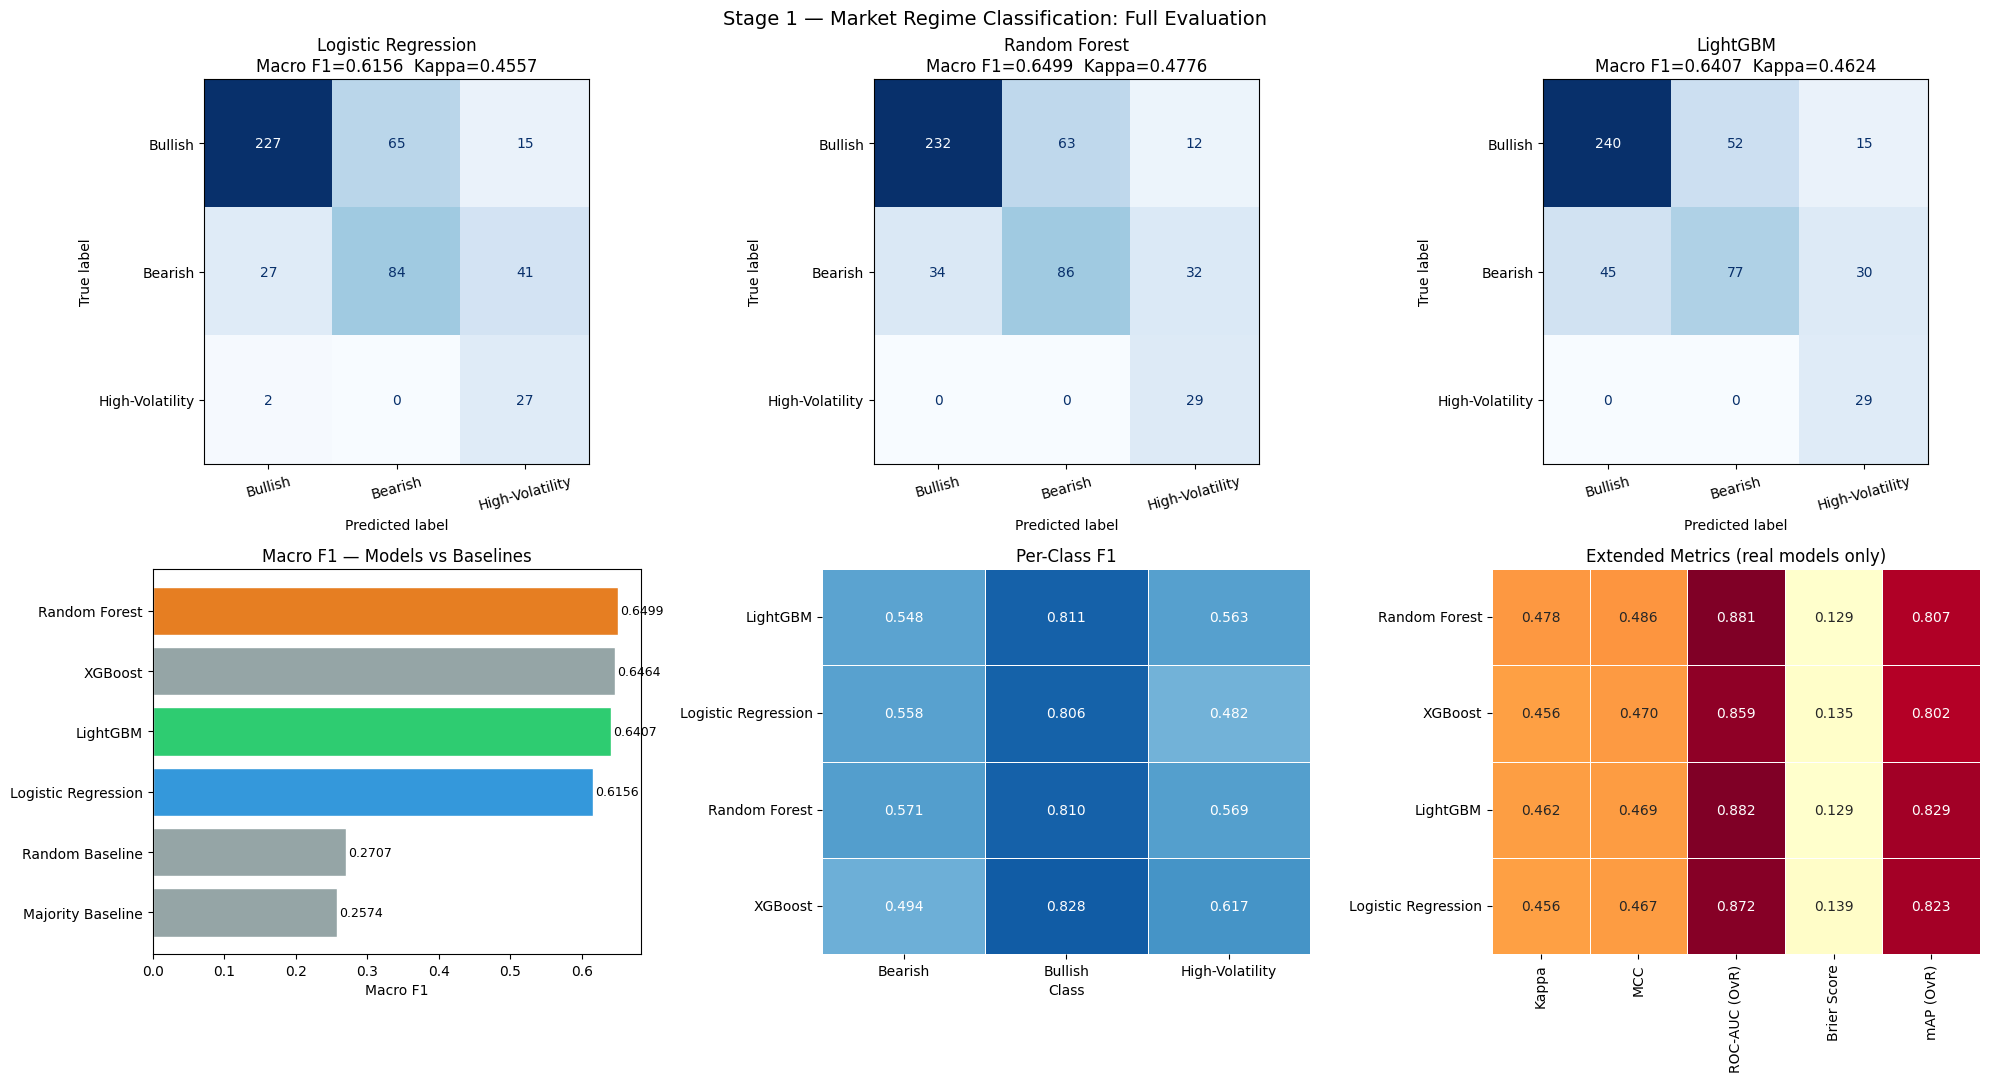

In [9]:
# ── Figure 1: Stage 1 Full Evaluation (2×3) ─────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Stage 1 — Market Regime Classification: Full Evaluation', fontsize=14)

# Row 1: Confusion matrices
for ax, (name, yp) in zip(axes[0], preds_s1.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test_s1, yp),
                           display_labels=list(REGIME_NAMES.values())
                          ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nMacro F1={f1_score(y_test_s1, yp, average="macro"):.4f}  '
                 f'Kappa={cohen_kappa_score(y_test_s1, yp):.4f}')
    ax.tick_params(axis='x', rotation=15)

# Row 2-left: Macro F1 bar (models vs baselines)
ax = axes[1, 0]
d = s1_summary.sort_values('Macro F1')
bars = ax.barh(d['Model'], d['Macro F1'],
               color=[MODEL_COLORS.get(m, '#95a5a6') for m in d['Model']], edgecolor='white')
for bar, val in zip(bars, d['Macro F1']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Macro F1'); ax.set_title('Macro F1 — Models vs Baselines')

# Row 2-center: Per-class F1 heatmap
ax = axes[1, 1]
sns.heatmap(per_class_s1_df.pivot(index='Model', columns='Class', values='F1'),
            annot=True, fmt='.3f', cmap='Blues', linewidths=0.5,
            ax=ax, vmin=0, vmax=1, cbar=False)
ax.set_title('Per-Class F1'); ax.set_ylabel('')

# Row 2-right: Extended metrics heatmap (Kappa, MCC, ROC-AUC, Brier)
ax = axes[1, 2]
ext_cols = ['Kappa', 'MCC', 'ROC-AUC (OvR)', 'Brier Score', 'mAP (OvR)']
ext_cols = [c for c in ext_cols if c in s1_summary.columns]
real_models = s1_summary[~s1_summary['Model'].str.contains('Baseline')]['Model'].tolist()
ext_df = s1_summary[s1_summary['Model'].isin(real_models)].set_index('Model')[ext_cols]
sns.heatmap(ext_df, annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5,
            ax=ax, cbar=False)
ax.set_title('Extended Metrics (real models only)'); ax.set_ylabel('')

plt.tight_layout()
plt.savefig('plots/evaluation/fig1_stage1_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
print("Stage 1 Figure 1 saved above.")


Stage 1 Figure 1 saved above.


---
## 5. Stage 2 Evaluation

In [11]:
rng2 = np.random.default_rng(SEED + 1)
rand_pred_s2  = rng2.integers(0, 3, size=len(y_test_s2))
rand_proba_s2 = np.ones((len(y_test_s2), 3)) / 3.0
majority_s2   = np.full(len(y_test_s2), np.bincount(y_test_s2).argmax())

s2_rows = []
for name, yp in preds_s2.items():
    yproba = baseline['s2'][name].predict_proba(X_test_s2)
    row = compute_metrics(y_test_s2, yp, yproba)
    row['Model'] = name; s2_rows.append(row)

s2_rows.append({**compute_metrics(y_test_s2, rand_pred_s2, rand_proba_s2),
                'Model': 'Random Baseline'})
s2_rows.append({**compute_metrics(y_test_s2, majority_s2),
                'Model': 'Majority Baseline'})

s2_summary = pd.DataFrame(s2_rows).sort_values('Macro F1', ascending=False).reset_index(drop=True)
s2_summary = s2_summary[[c for c in col_order if c in s2_summary.columns]]
print('=== Stage 2 — All Metrics ===')
print(s2_summary.to_string(index=False))

per_class_s2 = []
for name, yp in preds_s2.items():
    rpt = classification_report(y_test_s2, yp, output_dict=True)
    for k, v in SIGNAL_NAMES.items():
        per_class_s2.append({'Model': name, 'Class': v,
                              'Precision': rpt[str(k)]['precision'],
                              'Recall':    rpt[str(k)]['recall'],
                              'F1':        rpt[str(k)]['f1-score'],
                              'Support':   int(rpt[str(k)]['support'])})
per_class_s2_df = pd.DataFrame(per_class_s2)


=== Stage 2 — All Metrics ===
              Model  Accuracy  Balanced Acc  Macro F1  Weighted F1  Macro Prec  Macro Rec    Kappa      MCC  R2 (ordinal)  ROC-AUC (OvR)  ROC-AUC (OvO)  Log Loss  Brier Score  mAP (OvR)
Logistic Regression  0.315093      0.356318  0.290176     0.353755    0.357799   0.356318 0.025867 0.033363 -2.382203e+00       0.532645       0.532645  1.166957     0.234787   0.360250
    Random Baseline  0.334104      0.333360  0.289374     0.378557    0.333485   0.333360 0.000228 0.000272 -2.203482e+00       0.500000       0.500000  1.098612     0.222222   0.333333
            XGBoost  0.306303      0.361662  0.285995     0.341071    0.362663   0.361662 0.032027 0.042152 -2.460628e+00       0.546252       0.546252  1.160360     0.234164   0.363512
  Majority Baseline  0.697752      0.333333  0.273991     0.573533    0.232584   0.333333 0.000000 0.000000 -3.199121e-07            NaN            NaN       NaN          NaN        NaN
           LightGBM  0.286675      0.360

In [12]:
print("Stage 2 metrics computed — Figure 2 below consolidates all S2 visuals.")


Stage 2 metrics computed — Figure 2 below consolidates all S2 visuals.


In [13]:
print("See Figure 2 below.")


See Figure 2 below.


In [14]:
print("See Figure 2 below.")


See Figure 2 below.


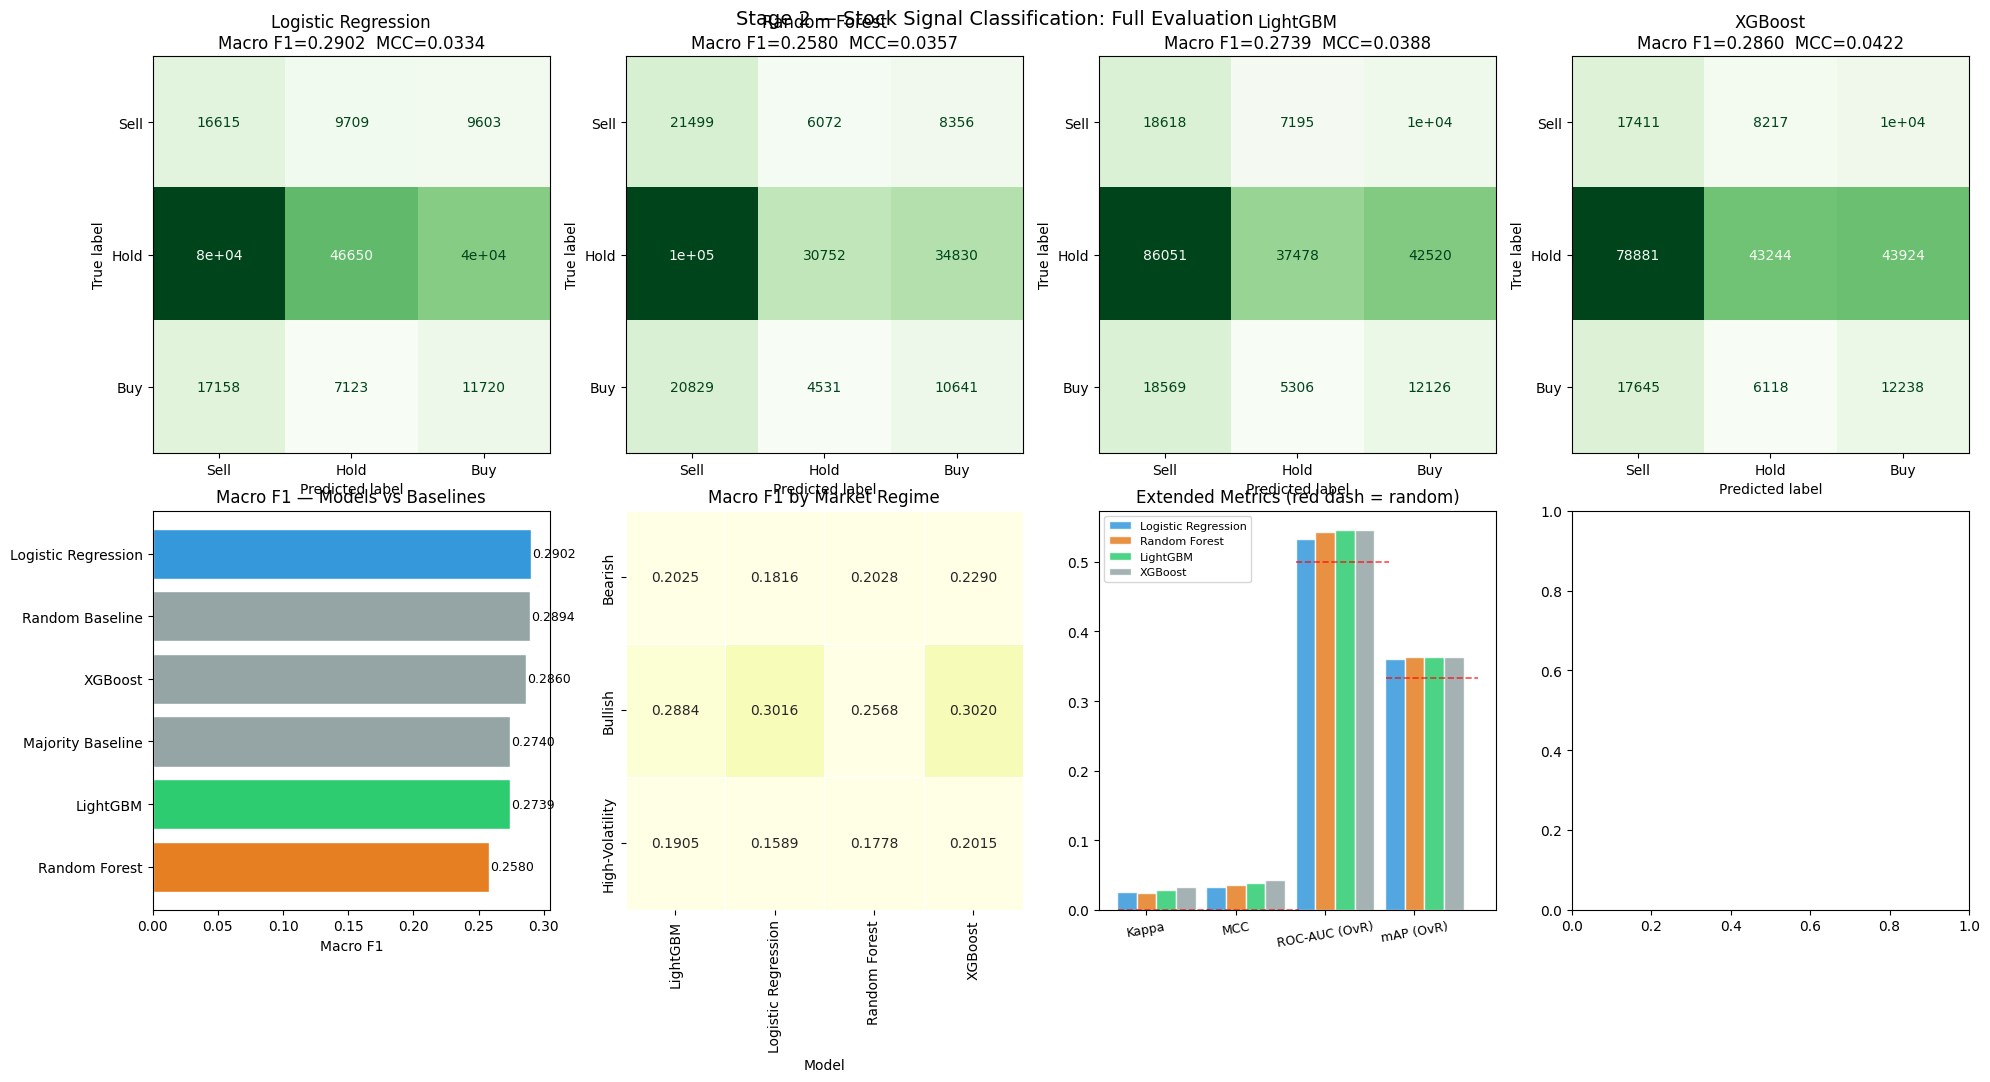

In [21]:
# ── Figure 2: Stage 2 Full Evaluation (2×3) ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(20, 11))
fig.suptitle('Stage 2 — Stock Signal Classification: Full Evaluation', fontsize=14)

# Row 1: Confusion matrices
for ax, (name, yp) in zip(axes[0], preds_s2.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test_s2, yp),
                           display_labels=list(SIGNAL_NAMES.values())
                          ).plot(ax=ax, colorbar=False, cmap='Greens')
    ax.set_title(f'{name}\nMacro F1={f1_score(y_test_s2, yp, average="macro"):.4f}  '
                 f'MCC={matthews_corrcoef(y_test_s2, yp):.4f}')

# Row 2-left: Macro F1 bar vs baselines
ax = axes[1, 0]
d = s2_summary.sort_values('Macro F1')
bars = ax.barh(d['Model'], d['Macro F1'],
               color=[MODEL_COLORS.get(m, '#95a5a6') for m in d['Model']], edgecolor='white')
for bar, val in zip(bars, d['Macro F1']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_xlabel('Macro F1'); ax.set_title('Macro F1 — Models vs Baselines')

# Row 2-center: Per-class F1 + regime-stratified heatmap (side by side in one ax via table)
ax = axes[1, 1]
# Regime-stratified performance
strat_rows = []
for regime_id, regime_name in REGIME_NAMES.items():
    mask  = test_s2['regime_pred'].values == regime_id if 'regime_pred' in test_s2.columns else np.zeros(len(test_s2), dtype=int) == regime_id
    if mask.sum() < 100: continue
    y_sub = y_test_s2[mask]
    for name, yp in preds_s2.items():
        strat_rows.append({
            'Regime': regime_name, 'Model': name,
            'N': int(mask.sum()),
            'Macro F1': f1_score(y_sub, yp[mask], average='macro', zero_division=0),
            'Accuracy': accuracy_score(y_sub, yp[mask]),
        })
strat_df = pd.DataFrame(strat_rows)
pivot_strat = strat_df.pivot(index='Regime', columns='Model', values='Macro F1')
sns.heatmap(pivot_strat, annot=True, fmt='.4f', cmap='YlGn',
            linewidths=0.5, ax=ax, vmin=0.28, vmax=0.45, cbar=False)
ax.set_title('Macro F1 by Market Regime'); ax.set_ylabel('')

# Row 2-right: Extended metrics grouped bar (Kappa, MCC, ROC-AUC, mAP)
ax = axes[1, 2]
real_models_s2 = [m for m in preds_s2.keys()]
ext_metrics    = ['Kappa', 'MCC', 'ROC-AUC (OvR)', 'mAP (OvR)']
ext_metrics    = [c for c in ext_metrics if c in s2_summary.columns]
x, w = np.arange(len(ext_metrics)), 0.22
for i, model in enumerate(real_models_s2):
    row_vals = [s2_summary.loc[s2_summary['Model']==model, m].values[0] for m in ext_metrics]
    ax.bar(x + i*w, row_vals, w, label=model,
           color=MODEL_COLORS.get(model, '#95a5a6'), alpha=0.85, edgecolor='white')
# Random baseline reference
rand_vals = [s2_summary.loc[s2_summary['Model']=='Random Baseline', m].values[0]
             if 'Random Baseline' in s2_summary['Model'].values and m in s2_summary.columns
             else 0 for m in ext_metrics]
for j, rv in enumerate(rand_vals):
    ax.plot([j - 0.1, j + len(real_models_s2)*w + 0.05], [rv, rv],
            'r--', lw=1.2, alpha=0.7)
ax.set_xticks(x + w); ax.set_xticklabels(ext_metrics, rotation=10, fontsize=9)
ax.set_title('Extended Metrics (red dash = random)'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('plots/evaluation/fig2_stage2_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Statistical Significance — McNemar's Test

In [16]:
from scipy.stats import wilcoxon, friedmanchisquare

def mcnemar_test(y_true, pred_a, pred_b):
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    b = np.sum(~correct_a &  correct_b)
    c = np.sum( correct_a & ~correct_b)
    if (b + c) == 0:
        return 0.0, 1.0
    chi2 = (abs(b - c) - 1) ** 2 / (b + c)
    p    = 1 - chi2_dist.cdf(chi2, df=1)
    return round(chi2, 3), round(p, 5)

model_names = list(preds_s1.keys())

print('=== Stage 1 — McNemar Pairwise Tests ===')
s1_mcnemar = []
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        a, b = model_names[i], model_names[j]
        chi2, p = mcnemar_test(y_test_s1, preds_s1[a], preds_s1[b])
        sig = '*** p<0.001' if p < 0.001 else ('** p<0.01' if p < 0.01 else
              ('* p<0.05' if p < 0.05 else 'n.s.'))
        s1_mcnemar.append({'Model A': a, 'Model B': b, 'chi2': chi2, 'p-value': p, 'Sig': sig})
        print(f'  {a} vs {b}: chi2={chi2}, p={p} -> {sig}')

print('\n=== Stage 2 — McNemar Pairwise Tests ===')
s2_mcnemar = []
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        a, b = model_names[i], model_names[j]
        chi2, p = mcnemar_test(y_test_s2, preds_s2[a], preds_s2[b])
        sig = '*** p<0.001' if p < 0.001 else ('** p<0.01' if p < 0.01 else
              ('* p<0.05' if p < 0.05 else 'n.s.'))
        s2_mcnemar.append({'Model A': a, 'Model B': b, 'chi2': chi2, 'p-value': p, 'Sig': sig})
        print(f'  {a} vs {b}: chi2={chi2}, p={p} -> {sig}')

s1_mcnemar_df = pd.DataFrame(s1_mcnemar)
s2_mcnemar_df = pd.DataFrame(s2_mcnemar)

# ── Friedman test (non-parametric multi-model comparison over folds) ─────────
print('\n=== Stage 2 — Friedman Test (per-sample correctness) ===')
correct_per_model = [preds_s2[m] == y_test_s2 for m in model_names]
stat, p_fried = friedmanchisquare(*correct_per_model)
print(f'Friedman chi2={stat:.3f}, p={p_fried:.5f} -> '
      f'{"Significant difference" if p_fried < 0.05 else "No significant difference"} among models')


=== Stage 1 — McNemar Pairwise Tests ===
  Logistic Regression vs Random Forest: chi2=1.939, p=0.16373 -> n.s.
  Logistic Regression vs LightGBM: chi2=1.021, p=0.31232 -> n.s.
  Logistic Regression vs XGBoost: chi2=2.753, p=0.09709 -> n.s.
  Random Forest vs LightGBM: chi2=0.0, p=1.0 -> n.s.
  Random Forest vs XGBoost: chi2=0.57, p=0.45035 -> n.s.
  LightGBM vs XGBoost: chi2=1.016, p=0.3135 -> n.s.

=== Stage 2 — McNemar Pairwise Tests ===
  Logistic Regression vs Random Forest: chi2=4181.795, p=0.0 -> *** p<0.001
  Logistic Regression vs LightGBM: chi2=1220.984, p=0.0 -> *** p<0.001
  Logistic Regression vs XGBoost: chi2=94.728, p=0.0 -> *** p<0.001
  Random Forest vs LightGBM: chi2=1033.039, p=0.0 -> *** p<0.001
  Random Forest vs XGBoost: chi2=2542.653, p=0.0 -> *** p<0.001
  LightGBM vs XGBoost: chi2=958.928, p=0.0 -> *** p<0.001

=== Stage 2 — Friedman Test (per-sample correctness) ===
Friedman chi2=4995.903, p=0.00000 -> Significant difference among models


---
## 7. Regime-Stratified Stage 2 Performance

In [17]:
print("Regime-stratified analysis embedded in Figure 2.")
print(strat_df.to_string(index=False))


Regime-stratified analysis embedded in Figure 2.
         Regime               Model      N  Macro F1  Accuracy
        Bullish Logistic Regression 138872  0.301557  0.403991
        Bullish       Random Forest 138872  0.256771  0.305814
        Bullish            LightGBM 138872  0.288367  0.345275
        Bullish             XGBoost 138872  0.301994  0.364494
        Bearish Logistic Regression  62234  0.181647  0.177748
        Bearish       Random Forest  62234  0.202759  0.203731
        Bearish            LightGBM  62234  0.202501  0.198846
        Bearish             XGBoost  62234  0.228990  0.229955
High-Volatility Logistic Regression  36871  0.158895  0.212091
High-Volatility       Random Forest  36871  0.177827  0.210030
High-Volatility            LightGBM  36871  0.190547  0.214206
High-Volatility             XGBoost  36871  0.201522  0.215996


---
## 8. Tuning Analysis — CV vs Holdout Gap

=== Stage 1: Baseline vs Optuna CV vs Tuned Holdout ===
              Model  Baseline Macro F1  Optuna CV F1  Tuned Macro F1     Delta
Logistic Regression             0.6156        0.7459        0.608207 -0.007393
      Random Forest             0.6500        0.7694        0.638441 -0.011559
           LightGBM             0.6410        0.7702        0.612351 -0.028649
            XGBoost             0.6460           NaN        0.642871 -0.003129

=== Stage 2: Baseline vs Optuna CV vs Tuned Holdout ===
              Model  Baseline Macro F1  Optuna CV F1  Tuned Macro F1     Delta
Logistic Regression              0.351        0.3615        0.293917 -0.057083
      Random Forest              0.338        0.3873        0.258999 -0.079001
           LightGBM              0.341        0.3660        0.285443 -0.055557
            XGBoost              0.342           NaN        0.352268  0.010268


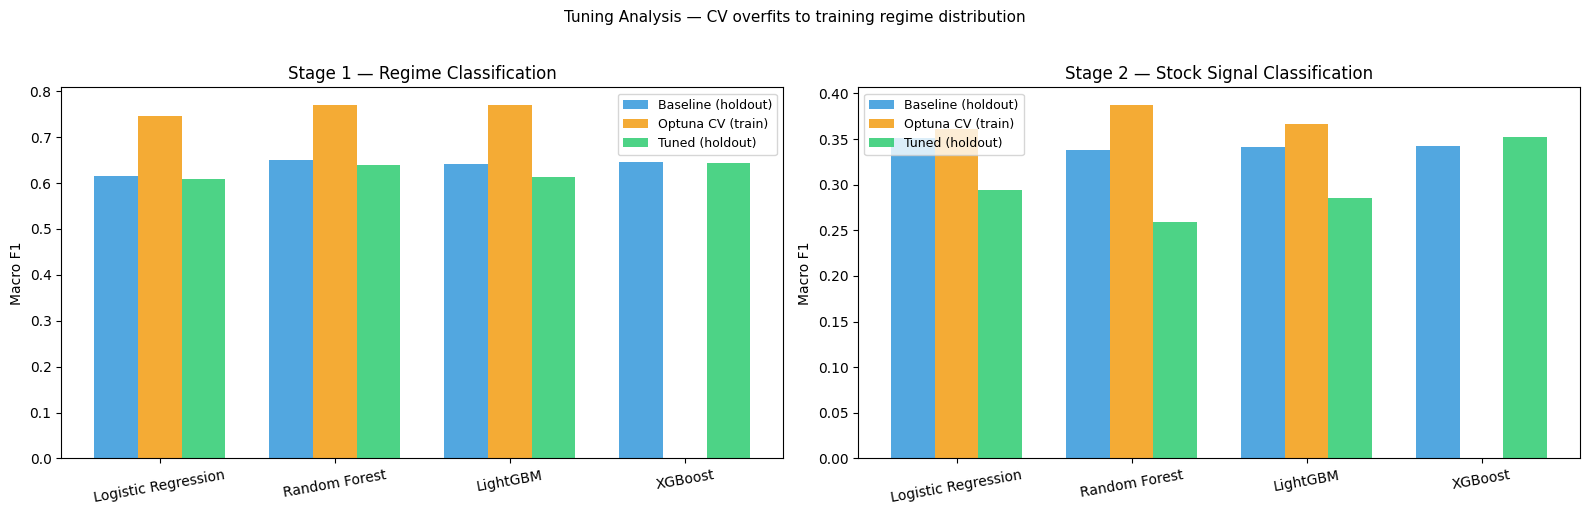

In [18]:
tuning_s1 = pd.read_csv('results/tuning_comparison_s1.csv')
tuning_s2 = pd.read_csv('results/tuning_comparison_s2.csv')

# Optuna best CV scores from optimization history plots
optuna_cv_s1 = {'Logistic Regression': 0.7459, 'Random Forest': 0.7694, 'LightGBM': 0.7702}
optuna_cv_s2 = {'Logistic Regression': 0.3615, 'Random Forest': 0.3873, 'LightGBM': 0.3660}
tuning_s1['Optuna CV F1'] = tuning_s1['Model'].map(optuna_cv_s1)
tuning_s2['Optuna CV F1'] = tuning_s2['Model'].map(optuna_cv_s2)

print('=== Stage 1: Baseline vs Optuna CV vs Tuned Holdout ===')
print(tuning_s1[['Model', 'Baseline Macro F1', 'Optuna CV F1', 'Tuned Macro F1', 'Delta']].to_string(index=False))
print()
print('=== Stage 2: Baseline vs Optuna CV vs Tuned Holdout ===')
print(tuning_s2[['Model', 'Baseline Macro F1', 'Optuna CV F1', 'Tuned Macro F1', 'Delta']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, (df_t, title) in zip(axes, [
    (tuning_s1, 'Stage 1 — Regime Classification'),
    (tuning_s2, 'Stage 2 — Stock Signal Classification')
]):
    x, w = np.arange(len(df_t)), 0.25
    ax.bar(x - w, df_t['Baseline Macro F1'], w, label='Baseline (holdout)', color='#3498db', alpha=0.85)
    ax.bar(x,     df_t['Optuna CV F1'], w, label='Optuna CV (train)', color='#f39c12', alpha=0.85)
    ax.bar(x + w, df_t['Tuned Macro F1'], w, label='Tuned (holdout)', color='#2ecc71', alpha=0.85)
    ax.set_xticks(x); ax.set_xticklabels(df_t['Model'], rotation=10)
    ax.set_ylabel('Macro F1'); ax.set_title(title); ax.legend(fontsize=9)
plt.suptitle('Tuning Analysis — CV overfits to training regime distribution', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('plots/evaluation/tuning_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Report Summary Figure

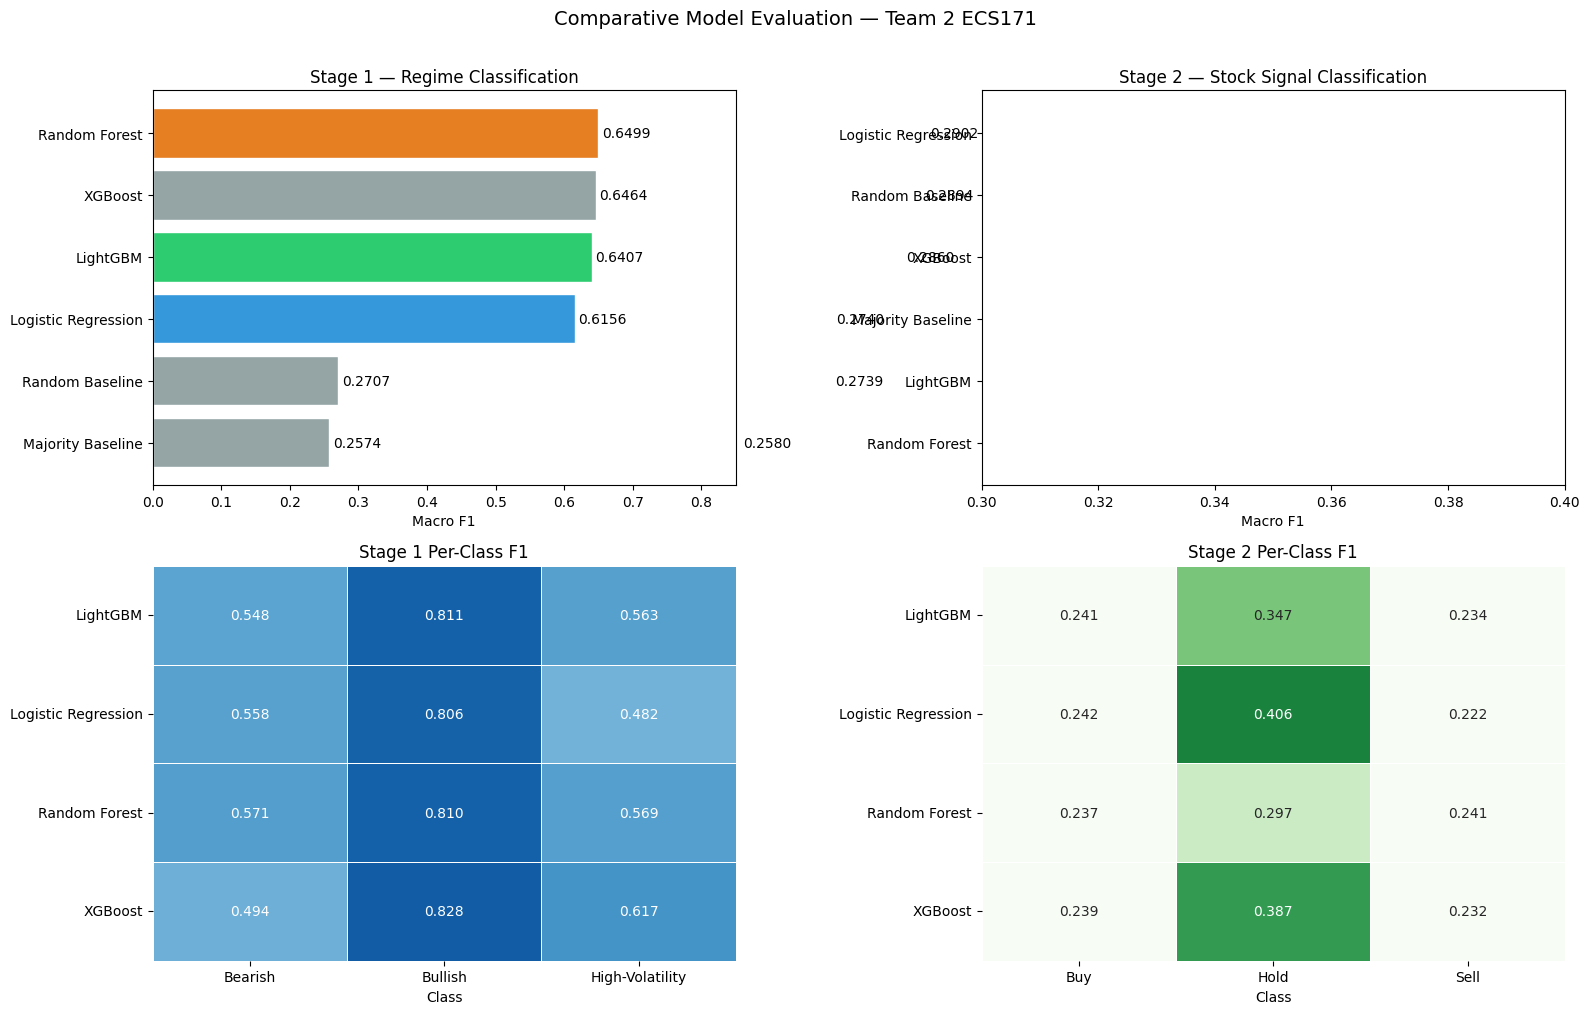

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: Stage 1 Macro F1
ax = axes[0, 0]
d = s1_summary.sort_values('Macro F1')
bars = ax.barh(d['Model'], d['Macro F1'],
               color=[MODEL_COLORS.get(m, '#95a5a6') for m in d['Model']], edgecolor='white')
for bar, val in zip(bars, d['Macro F1']):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Macro F1'); ax.set_title('Stage 1 — Regime Classification'); ax.set_xlim(0, 0.85)

# Top-right: Stage 2 Macro F1
ax = axes[0, 1]
d = s2_summary.sort_values('Macro F1')
bars = ax.barh(d['Model'], d['Macro F1'],
               color=[MODEL_COLORS.get(m, '#95a5a6') for m in d['Model']], edgecolor='white')
for bar, val in zip(bars, d['Macro F1']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Macro F1'); ax.set_title('Stage 2 — Stock Signal Classification'); ax.set_xlim(0.30, 0.40)

# Bottom-left: Stage 1 per-class F1 heatmap
ax = axes[1, 0]
sns.heatmap(per_class_s1_df.pivot(index='Model', columns='Class', values='F1'),
            annot=True, fmt='.3f', cmap='Blues', linewidths=0.5,
            ax=ax, vmin=0, vmax=1, cbar=False)
ax.set_title('Stage 1 Per-Class F1'); ax.set_ylabel('')

# Bottom-right: Stage 2 per-class F1 heatmap
ax = axes[1, 1]
sns.heatmap(per_class_s2_df.pivot(index='Model', columns='Class', values='F1'),
            annot=True, fmt='.3f', cmap='Greens', linewidths=0.5,
            ax=ax, vmin=0.25, vmax=0.45, cbar=False)
ax.set_title('Stage 2 Per-Class F1'); ax.set_ylabel('')

plt.suptitle('Comparative Model Evaluation — Team 2 ECS171', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('plots/evaluation/report_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Save All Results

In [20]:
s1_summary.to_csv('results/eval_s1_summary.csv', index=False)
s2_summary.to_csv('results/eval_s2_summary.csv', index=False)
per_class_s1_df.to_csv('results/eval_s1_perclass.csv', index=False)
per_class_s2_df.to_csv('results/eval_s2_perclass.csv', index=False)
strat_df.to_csv('results/eval_regime_stratified.csv', index=False)
s1_mcnemar_df.to_csv('results/eval_mcnemar_s1.csv', index=False)
s2_mcnemar_df.to_csv('results/eval_mcnemar_s2.csv', index=False)

print('All results saved.')
print()
print('=== KEY FINDINGS ===')
real = s1_summary[~s1_summary['Model'].str.contains('Baseline')]
rand = s1_summary[s1_summary['Model'] == 'Random Baseline']
best_s1 = real.iloc[0]; best_s2 = s2_summary[~s2_summary['Model'].str.contains('Baseline')].iloc[0]
rand_s2 = s2_summary[s2_summary['Model'] == 'Random Baseline'].iloc[0]
print(f'Best S1: {best_s1["Model"]}  F1={best_s1["Macro F1"]:.4f}  '
      f'Kappa={best_s1["Kappa"]:.4f}  MCC={best_s1["MCC"]:.4f}  '
      f'ROC-AUC={best_s1.get("ROC-AUC (OvR)", float("nan")):.4f}')
print(f'Best S2: {best_s2["Model"]}  F1={best_s2["Macro F1"]:.4f}  '
      f'Kappa={best_s2["Kappa"]:.4f}  MCC={best_s2["MCC"]:.4f}  '
      f'ROC-AUC={best_s2.get("ROC-AUC (OvR)", float("nan")):.4f}')
print(f'S2 vs random: Δ F1={best_s2["Macro F1"]-rand_s2["Macro F1"]:+.4f}  '
      f'Δ Kappa={best_s2["Kappa"]-rand_s2["Kappa"]:+.4f}')
print()
print('McNemar Stage 2:')
print(s2_mcnemar_df[['Model A','Model B','p-value','Sig']].to_string(index=False))


All results saved.

=== KEY FINDINGS ===
Best S1: Random Forest  F1=0.6499  Kappa=0.4776  MCC=0.4857  ROC-AUC=0.8810
Best S2: Logistic Regression  F1=0.2902  Kappa=0.0259  MCC=0.0334  ROC-AUC=0.5326
S2 vs random: Δ F1=+0.0008  Δ Kappa=+0.0256

McNemar Stage 2:
            Model A       Model B  p-value         Sig
Logistic Regression Random Forest      0.0 *** p<0.001
Logistic Regression      LightGBM      0.0 *** p<0.001
Logistic Regression       XGBoost      0.0 *** p<0.001
      Random Forest      LightGBM      0.0 *** p<0.001
      Random Forest       XGBoost      0.0 *** p<0.001
           LightGBM       XGBoost      0.0 *** p<0.001
